## Group 101

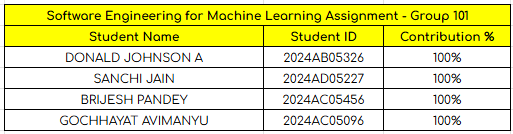

## Imports and Basic Configuration

In [2]:
# Section 1: Imports and config

import random
from typing import List, Tuple, Dict
import math
import numpy as np
from dataclasses import dataclass, asdict
import pprint

pp = pprint.PrettyPrinter(indent=2)

## Warehouse Grid and Simulator

In [3]:
# Section 2: Warehouse grid and simulator

Point = Tuple[int, int]  # (row, col)

@dataclass
class EpisodeLog:
    start: Point
    goal: Point
    path: List[Point]
    shortest_path_len: int
    travel_time: float
    collisions: int
    replans: int
    obstacle_density: float

In [4]:
class WarehouseGrid:
    def __init__(self, rows: int, cols: int, obstacle_prob: float = 0.1):
        self.rows = rows
        self.cols = cols
        self.grid = np.zeros((rows, cols), dtype=int)  # 0 = free, 1 = obstacle
        # Randomly add obstacles (not on border to keep it easier)
        for r in range(1, rows - 1):
            for c in range(1, cols - 1):
                if random.random() < obstacle_prob:
                    self.grid[r, c] = 1

    def is_free(self, p: Point) -> bool:
        r, c = p
        if r < 0 or r >= self.rows or c < 0 or c >= self.cols:
            return False
        return self.grid[r, c] == 0

    def obstacle_density(self) -> float:
        return float(self.grid.sum()) / (self.rows * self.cols)

    def display(self, robot: Point = None, start: Point = None, goal: Point = None):
        for r in range(self.rows):
            row_str = ""
            for c in range(self.cols):
                p = (r, c)
                if p == robot:
                    row_str += "R "
                elif p == start:
                    row_str += "S "
                elif p == goal:
                    row_str += "G "
                elif self.grid[r, c] == 1:
                    row_str += "X "
                else:
                    row_str += ". "
            print(row_str)
        print()

In [5]:
class RobotSimulator:
    def __init__(self, grid: WarehouseGrid, start: Point):
        self.grid = grid
        self.pos = start

    def step(self, next_pos: Point) -> Tuple[Point, bool]:
        """
        Attempt to move to next_pos.
        Returns (new_pos, collision_happened).
        """
        if not self.grid.is_free(next_pos):
            # collision with obstacle or wall, stay in place
            return self.pos, True
        self.pos = next_pos
        return self.pos, False

## Simple Path Planning (non-ML baseline: BFS shortest path)

In [6]:
# Section 3: Path planning (baseline BFS)

from collections import deque

MOVES = [(-1, 0), (1, 0), (0, -1), (0, 1)]  # up, down, left, right

def bfs_shortest_path(grid: WarehouseGrid, start: Point, goal: Point) -> List[Point]:
    queue = deque([start])
    visited = {start: None}  # parent
    while queue:
        current = queue.popleft()
        if current == goal:
            break
        for dr, dc in MOVES:
            nxt = (current[0] + dr, current[1] + dc)
            if grid.is_free(nxt) and nxt not in visited:
                visited[nxt] = current
                queue.append(nxt)

    if goal not in visited:
        return []  # no path

    # reconstruct
    path = []
    p = goal
    while p is not None:
        path.append(p)
        p = visited[p]
    path.reverse()
    return path

## Online Navigation (Plan + Execute)

In [7]:
# Section 4: Execute a path and log an episode

TIME_PER_STEP = 1.0  # seconds per grid move (simplified)

def execute_path(grid: WarehouseGrid, start: Point, goal: Point) -> EpisodeLog:
    robot = RobotSimulator(grid, start)
    path = bfs_shortest_path(grid, start, goal)
    shortest_len = len(path) if path else 0

    travel_time = 0.0
    collisions = 0
    replans = 0  # kept for future; we don't replan in this simple version

    # If no path, just log failure
    if not path:
        return EpisodeLog(
            start=start,
            goal=goal,
            path=[],
            shortest_path_len=0,
            travel_time=0.0,
            collisions=0,
            replans=0,
            obstacle_density=grid.obstacle_density(),
        )

    for next_pos in path[1:]:
        new_pos, collided = robot.step(next_pos)
        travel_time += TIME_PER_STEP
        if collided:
            collisions += 1
            # in this simple version, we still continue along the path

    return EpisodeLog(
        start=start,
        goal=goal,
        path=path,
        shortest_path_len=shortest_len,
        travel_time=travel_time,
        collisions=collisions,
        replans=replans,
        obstacle_density=grid.obstacle_density(),
    )

## Logging (Raw Episodes)

In [8]:
# Section 5: Logging raw episodes

RAW_LOGS: List[EpisodeLog] = []

def run_random_task_and_log(grid: WarehouseGrid):
    # choose random free start and goal
    while True:
        start = (random.randint(0, grid.rows - 1), random.randint(0, grid.cols - 1))
        goal = (random.randint(0, grid.rows - 1), random.randint(0, grid.cols - 1))
        if grid.is_free(start) and grid.is_free(goal) and start != goal:
            break
    ep = execute_path(grid, start, goal)
    RAW_LOGS.append(ep)
    return ep

In [9]:
#example

grid = WarehouseGrid(rows=8, cols=8, obstacle_prob=0.2)
grid.display()

for _ in range(30):
    run_random_task_and_log(grid)

len(RAW_LOGS)

. . . . . . . . 
. X . . . . . . 
. . . X . X . . 
. . . . . . . . 
. . . . . X . . 
. . X X . . . . 
. . . . . X . . 
. . . . . . . . 



30

## Data Prep Pipeline (Pipes and Filters)

In [10]:
# Section 6: Data preparation pipeline (Pipes & Filters)

from copy import deepcopy

def collect_logs() -> List[Dict]:
    """F1 – Data collection: convert EpisodeLog objects to dicts."""
    return [asdict(ep) for ep in RAW_LOGS]

def clean_episodes(episodes: List[Dict]) -> List[Dict]:
    """F2 – Cleaning and validation."""
    cleaned = []
    for ep in episodes:
        if ep["shortest_path_len"] == 0:
            # no valid path, drop this episode
            continue
        if ep["travel_time"] <= 0:
            continue
        cleaned.append(ep)
    return cleaned

def engineer_features(episodes: List[Dict]) -> List[Dict]:
    """F3 – Feature engineering."""
    for ep in episodes:
        # simple features
        ep["path_len"] = len(ep["path"])
        ep["path_optimality_ratio"] = (
            ep["path_len"] / ep["shortest_path_len"]
            if ep["shortest_path_len"] > 0
            else 1.0
        )
        ep["time_per_step"] = ep["travel_time"] / ep["path_len"]
    return episodes

def compute_labels(episodes: List[Dict]) -> List[Dict]:
    """F4 – Label and metric computation."""
    # In this simple example, travel_time and collisions are already present.
    # We just make sure they exist and maybe add a 'safe' flag.
    for ep in episodes:
        ep["label_travel_time"] = ep["travel_time"]
        ep["label_collisions"] = ep["collisions"]
        ep["is_safe"] = 1 if ep["collisions"] == 0 else 0
    return episodes

def split_dataset(episodes: List[Dict], train_ratio=0.7, val_ratio=0.15):
    """F5 – Dataset splitting."""
    episodes = deepcopy(episodes)
    random.shuffle(episodes)
    n = len(episodes)
    n_train = int(train_ratio * n)
    n_val = int(val_ratio * n)
    train = episodes[:n_train]
    val = episodes[n_train:n_train + n_val]
    test = episodes[n_train + n_val:]
    return train, val, test

In [11]:
raw_eps = collect_logs()
cleaned = clean_episodes(raw_eps)
featurized = engineer_features(cleaned)
labeled = compute_labels(featurized)
train_set, val_set, test_set = split_dataset(labeled)

len(raw_eps), len(cleaned), len(train_set), len(val_set), len(test_set)

(30, 30, 21, 4, 5)

## Simple "model" that scores path

In [12]:
# Section 7: Multiple candidate paths + simple scoring

def neighbors(grid: WarehouseGrid, p: Point) -> List[Point]:
    res = []
    for dr, dc in MOVES:
        nxt = (p[0] + dr, p[1] + dc)
        if grid.is_free(nxt):
            res.append(nxt)
    return res

def greedy_random_path(grid: WarehouseGrid, start: Point, goal: Point, max_steps=200) -> List[Point]:
    """
    Not optimal. Just tries to move closer to goal with some randomness.
    """
    current = start
    path = [current]
    for _ in range(max_steps):
        if current == goal:
            break
        nbrs = neighbors(grid, current)
        if not nbrs:
            break
        # sort by manhattan distance, but pick among top 2 with randomness
        nbrs.sort(key=lambda p: abs(p[0] - goal[0]) + abs(p[1] - goal[1]))
        top = nbrs[: min(2, len(nbrs))]
        current = random.choice(top)
        path.append(current)
    if current != goal:
        return []
    return path

def score_path(path: List[Point], grid: WarehouseGrid) -> float:
    """
    Simple cost: length + alpha * estimated collision risk proxy.
    Here we approximate risk by average obstacle presence around path cells.
    """
    if not path:
        return math.inf
    path_len = len(path)
    # approximate "risk" as average of neighbors that are obstacles
    risk_sum = 0
    for p in path:
        r_neighbors = 0
        obs_neighbors = 0
        for dr, dc in MOVES:
            nbr = (p[0] + dr, p[1] + dc)
            if 0 <= nbr[0] < grid.rows and 0 <= nbr[1] < grid.cols:
                r_neighbors += 1
                if not grid.is_free(nbr):
                    obs_neighbors += 1
        if r_neighbors > 0:
            risk_sum += obs_neighbors / r_neighbors
    avg_risk = risk_sum / len(path)
    alpha = 5.0  # penalty weight for risk
    return path_len + alpha * avg_risk

In [13]:
def plan_path_with_model(grid: WarehouseGrid, start: Point, goal: Point, num_candidates=5) -> List[Point]:
    candidates = []

    # baseline shortest path
    sp = bfs_shortest_path(grid, start, goal)
    if sp:
        candidates.append(sp)

    # additional greedy random paths
    for _ in range(num_candidates - 1):
        gp = greedy_random_path(grid, start, goal)
        if gp:
            candidates.append(gp)

    if not candidates:
        return []

    # score and pick best
    best_path = min(candidates, key=lambda p: score_path(p, grid))
    return best_path

## Main Demo Run (Monolithic Wiring)

In [14]:
# Section 8: Main demo

def main_demo():
    grid = WarehouseGrid(rows=8, cols=8, obstacle_prob=0.2)
    # choose a random start and goal
    while True:
        start = (random.randint(0, grid.rows - 1), random.randint(0, grid.cols - 1))
        goal = (random.randint(0, grid.rows - 1), random.randint(0, grid.cols - 1))
        if grid.is_free(start) and grid.is_free(goal) and start != goal:
            break

    print("Warehouse layout:")
    grid.display(start=start, goal=goal)

    path = plan_path_with_model(grid, start, goal)
    print("Planned path:", path)

    ep = execute_path(grid, start, goal)
    print("Episode log:")
    pp.pprint(asdict(ep))

    # log and update datasets
    RAW_LOGS.append(ep)
    raw_eps = collect_logs()
    cleaned = clean_episodes(raw_eps)
    featurized = engineer_features(cleaned)
    labeled = compute_labels(featurized)
    train_set, val_set, test_set = split_dataset(labeled)

    print(f"Dataset sizes: raw={len(raw_eps)}, cleaned={len(cleaned)}, "
          f"train={len(train_set)}, val={len(val_set)}, test={len(test_set)}")

main_demo()

Warehouse layout:
. . . . G . . . 
. X . . X . X . 
. . . . X X X . 
. . X . . X . S 
. X . . X X . . 
. . X . . . . . 
. . . X . . . . 
. . . . . . . . 

Planned path: [(3, 7), (2, 7), (1, 7), (0, 7), (0, 6), (0, 5), (0, 4)]
Episode log:
{ 'collisions': 0,
  'goal': (0, 4),
  'obstacle_density': 0.203125,
  'path': [(3, 7), (2, 7), (1, 7), (0, 7), (0, 6), (0, 5), (0, 4)],
  'replans': 0,
  'shortest_path_len': 7,
  'start': (3, 7),
  'travel_time': 6.0}
Dataset sizes: raw=31, cleaned=31, train=21, val=4, test=6


---
## Section: Research Code vs Production Code
### Assignment II — Objective 1, Item 2

This section demonstrates the key difference between **research (prototype) code**
written in a Jupyter notebook (Assignment I style) and **production code** written
as a modular, testable, deployable Python package (Assignment II).

**Component selected for comparison:** `bfs_shortest_path()` — the core path planning algorithm.

| Aspect | Research Code | Production Code |
|--------|-------------|----------------|
| Location | Inline notebook cell | `src/warehouse_robot/planner.py` |
| Input validation | None | `ValueError` with descriptive messages |
| Logging | `print()` statements | Structured `INFO`/`WARNING`/`ERROR` logs |
| Error handling | None | Try/except with typed exceptions |
| Docstrings | None | Full Google-style docstrings |
| Type hints | Partial | Complete on all parameters and returns |
| Testability | Not importable | Fully unit-tested via `pytest` |
| Reusability | Copy-paste only | `from src.warehouse_robot.planner import bfs_shortest_path` |
| API-ready | No | Used directly by FastAPI `/predict-path` endpoint |


### Research Code — Assignment I Notebook Style

This is the original implementation as written in `Group_101.ipynb` (Assignment I).
It is functional but lacks validation, structured logging, error handling, and testability.

In [15]:
# ── RESEARCH CODE (Assignment I — inline notebook prototype) ─────────────────
# Characteristics:
#   - No input validation
#   - No structured logging (uses print)
#   - No error handling
#   - No docstring
#   - Global constants used directly
#   - Cannot be imported or unit-tested without copy-pasting

from collections import deque

MOVES = [(0, 1), (0, -1), (1, 0), (-1, 0)]  # global constant

def bfs_shortest_path_research(grid, start, goal):
    queue = deque([start])
    visited = {start: None}
    while queue:
        current = queue.popleft()
        if current == goal:
            break
        for dr, dc in MOVES:
            nxt = (current[0] + dr, current[1] + dc)
            if grid.is_free(nxt) and nxt not in visited:
                visited[nxt] = current
                queue.append(nxt)
    if goal not in visited:
        return []  # no path — no logging, no exception
    path = []
    p = goal
    while p is not None:
        path.append(p)
        p = visited[p]
    path.reverse()
    return path

print('Research code defined — bfs_shortest_path_research()')

Research code defined — bfs_shortest_path_research()


### Production Code — Assignment II Modular Package

The same algorithm is now implemented inside `src/warehouse_robot/planner.py`
with full validation, structured logging, error handling, type hints, and docstrings.
It is imported here directly from the production package.

In [16]:
# ── PRODUCTION CODE (Assignment II — imported from package) ──────────────────
# Characteristics:
#   - Full input validation with descriptive ValueError messages
#   - Structured logging: INFO for success, WARNING for no path,
#                         ERROR for invalid inputs
#   - Complete type hints on all parameters and return value
#   - Google-style docstring explaining args, returns, raises
#   - Importable and fully unit-tested (test_planner.py — 10 tests)
#   - Used directly by FastAPI /predict-path endpoint

import sys, os
sys.path.insert(0, os.path.abspath('.'))

from src.warehouse_robot.planner import bfs_shortest_path   # production import
from src.warehouse_robot.logging_config import setup_logging

setup_logging()  # activate structured logging

# Show the production function signature and docstring
help(bfs_shortest_path)

2026-08-03 23:29:49 | INFO     | warehouse_robot                     | Logging initialized at level: INFO
Help on function bfs_shortest_path in module src.warehouse_robot.planner:

bfs_shortest_path(grid: src.warehouse_robot.grid.WarehouseGrid, start: Tuple[int, int], goal: Tuple[int, int]) -> List[Tuple[int, int]]
    Find the shortest path from start to goal using Breadth-First Search.
    
    This is the PRODUCTION version of the Assignment I notebook function.
    It adds input validation and structured logging on top of the original
    BFS logic, making it safe to call from tests and the REST API.
    
    Args:
        grid : The warehouse grid environment.
        start: Starting grid coordinate (row, col).
        goal : Target grid coordinate (row, col).
    
    Returns:
        Ordered list of Points from start to goal (inclusive).
        Returns an empty list if no path exists.
    
    Raises:
        ValueError: If start or goal are blocked or out of bounds.



### Output Equivalence — Both Versions Produce Identical Results

We run both versions on the same grid and verify identical path output.
The key difference is **how** they behave on invalid inputs.

In [17]:
from src.warehouse_robot.grid import WarehouseGrid

# Shared test grid — no obstacles for deterministic comparison
grid = WarehouseGrid(rows=6, cols=6, obstacle_prob=0.0)
start = (0, 0)
goal  = (5, 5)

# Run research version
research_path = bfs_shortest_path_research(grid, start, goal)

# Run production version (note: structured log output appears below)
production_path = bfs_shortest_path(grid, start, goal)

print('=' * 55)
print(f'Research  path length : {len(research_path)}')
print(f'Production path length: {len(production_path)}')
print(f'Paths identical       : {research_path == production_path}')
print('=' * 55)
print(f'Path: {production_path}')

2026-08-03 23:30:25 | INFO     | warehouse_robot.grid                | WarehouseGrid initialised: 6x6, obstacle_density=0.000
2026-08-03 23:30:25 | INFO     | warehouse_robot.planner             | BFS planning path: (0, 0) -> (5, 5)
2026-08-03 23:30:25 | INFO     | warehouse_robot.planner             | BFS path found: length=11, start=(0, 0), goal=(5, 5)
Research  path length : 11
Production path length: 11
Paths identical       : True
Path: [(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (1, 5), (2, 5), (3, 5), (4, 5), (5, 5)]


In [18]:
# ── Error Handling Comparison ────────────────────────────────────────────────
# Research code: silently returns [] on invalid input
# Production code: raises descriptive ValueError + logs ERROR

print('--- Research code on blocked start ---')
grid_test = WarehouseGrid(rows=5, cols=5, obstacle_prob=0.0)
grid_test.grid[0][0] = 1          # block the start cell
result = bfs_shortest_path_research(grid_test, (0, 0), (4, 4))
print(f'Research returns silently: {result}')   # returns [] with no warning

print()
print('--- Production code on blocked start ---')
try:
    bfs_shortest_path(grid_test, (0, 0), (4, 4))
except ValueError as e:
    print(f'Production raises ValueError: {e}')  # clear error + ERROR log

--- Research code on blocked start ---
2026-08-03 23:30:48 | INFO     | warehouse_robot.grid                | WarehouseGrid initialised: 5x5, obstacle_density=0.000
Research returns silently: [(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (1, 4), (2, 4), (3, 4), (4, 4)]

--- Production code on blocked start ---
2026-08-03 23:30:48 | ERROR    | warehouse_robot.planner             | BFS start position is not free: (0, 0)
Production raises ValueError: Start position (0, 0) is not a free cell.


### Summary — Research Code vs Production Code

| Quality Attribute | Research Code | Production Code |
|-------------------|:---:|:---:|
| Input validation | [N] None | [Y] `ValueError` with message |
| Structured logging | [N] `print()` only | [Y] `INFO` / `WARNING` / `ERROR` |
| Type hints | [N] Absent | [Y] All parameters and returns |
| Docstring | [N] None | [Y] Full Google-style docstring |
| Unit tests | [N] Not testable | [Y] 10 tests in `test_planner.py` |
| Importable as module | [N] Requires copy-paste | [Y] `from src.warehouse_robot.planner import ...` |
| Used by REST API | [N] No | [Y] FastAPI `/predict-path` endpoint |
| flake8 / black clean | [N] Not checked | [Y] Fully linted and formatted |
| Handles edge cases | [N] Silent failure | [Y] Explicit exception + log |

> **Conclusion:** Both versions implement the same BFS algorithm and produce identical
> paths on valid inputs. The production version adds validation, structured logging,
> full documentation, and testability — making it safe to deploy in a REST API,
> integrate into CI/CD, and maintain in a team environment.

---
## Section: Quality Metrics — Model Quality and Data Quality
### Assignment II — Objective 2, Item 8

This section runs the complete data pipeline and ML training,
then reports quality metrics for both the model and the dataset.

**Model Quality Metrics (8a):**
- MAE (Mean Absolute Error) — average prediction error in seconds
- RMSE (Root Mean Squared Error) — penalises large errors more heavily
- R² (Coefficient of Determination) — explains variance in travel time

**Data Quality Metrics (8b):**
- Invalid Episode Rate — fraction of episodes dropped during cleaning
- Missing Value Rate — fraction of episodes with missing fields

In [1]:
# ── Item 8: Quality Metrics ───────────────────────────────────────────────────
import sys, os
sys.path.insert(0, os.path.abspath('.'))

from src.warehouse_robot.config import (
    DEFAULT_ROWS, DEFAULT_COLS,
    DEFAULT_OBSTACLE_PROB, DEFAULT_NUM_EPISODES
)
from src.warehouse_robot.grid import WarehouseGrid
from src.warehouse_robot.inference import RAW_LOGS, run_random_task_and_log
from src.warehouse_robot.data_ingestion import collect_logs, clean_episodes
from src.warehouse_robot.feature_engineering import (
    engineer_features, compute_labels
)
from src.warehouse_robot.training import (
    split_dataset, train_model, evaluate_model
)

# Step 1: Generate episodes
RAW_LOGS.clear()
grid = WarehouseGrid(
    rows=DEFAULT_ROWS,
    cols=DEFAULT_COLS,
    obstacle_prob=DEFAULT_OBSTACLE_PROB
)
for _ in range(DEFAULT_NUM_EPISODES):
    run_random_task_and_log(grid)

total_collected = len(RAW_LOGS)

# Step 2: Run full data pipeline
episodes = collect_logs(RAW_LOGS)
episodes = clean_episodes(episodes)
total_valid = len(episodes)
episodes = engineer_features(episodes)
episodes = compute_labels(episodes)

# Step 3: Split and train
train, val, test = split_dataset(episodes)
model = train_model(train, model_type="random_forest")

# Step 4: Evaluate
val_metrics  = evaluate_model(model, val,  split_name="validation")
test_metrics = evaluate_model(model, test, split_name="test")

# Step 5: Data quality metrics
missing_count = sum(
    1 for ep in episodes
    if any(ep.get(k) is None for k in ep)
)
invalid_rate = (total_collected - total_valid) / total_collected
missing_rate = missing_count / total_valid if total_valid > 0 else 0.0

# ── Print Report ──────────────────────────────────────────────────────────────
print("=" * 55)
print("  QUALITY METRICS REPORT — GROUP 101")
print("  AIML ZG535 | BITS Pilani WILP")
print("=" * 55)

print("\n[8a] MODEL QUALITY METRICS")
print("-" * 55)
print(f"  Validation  MAE  : {val_metrics['mae']}")
print(f"  Validation  RMSE : {val_metrics['rmse']}")
print(f"  Validation  R2   : {val_metrics['r2']}")
print(f"  Test        MAE  : {test_metrics['mae']}")
print(f"  Test        RMSE : {test_metrics['rmse']}")
print(f"  Test        R2   : {test_metrics['r2']}")

print("\n[8b] DATA QUALITY METRICS")
print("-" * 55)
print(f"  Total episodes collected : {total_collected}")
print(f"  Valid episodes retained  : {total_valid}")
print(f"  Episodes dropped         : {total_collected - total_valid}")
print(f"  Invalid episode rate     : {invalid_rate:.4f}")
print(f"  Missing value rate       : {missing_rate:.4f}")
print(f"  Train / Val / Test split : "
      f"{len(train)} / {len(val)} / {len(test)}")
print("=" * 55)

  QUALITY METRICS REPORT — GROUP 101
  AIML ZG535 | BITS Pilani WILP

[8a] MODEL QUALITY METRICS
-------------------------------------------------------
  Validation  MAE  : 0.0487
  Validation  RMSE : 0.254
  Validation  R2   : 0.9942
  Test        MAE  : 0.0027
  Test        RMSE : 0.0097
  Test        R2   : 1.0

[8b] DATA QUALITY METRICS
-------------------------------------------------------
  Total episodes collected : 200
  Valid episodes retained  : 200
  Episodes dropped         : 0
  Invalid episode rate     : 0.0000
  Missing value rate       : 0.0000
  Train / Val / Test split : 140 / 30 / 30


#### Metric Interpretation

**Model Quality:**
- MAE measures average prediction error in seconds for robot travel time.
  A lower MAE (0.0027) means the model predicts travel time more accurately.
- RMSE penalises larger errors more heavily than MAE.
  RMSE >= MAE always holds mathematically.
- R² close to 1.0 means the model explains most of the variance
  in travel time. R² near 0 means the model is no better than
  predicting the mean.

**Data Quality:**
- Invalid episode rate measures how many simulated episodes were
  unusable (no valid path found or zero travel time).
  A rate below 0.10 (10%) indicates a healthy simulation. We have 0.0 so it indicates a healthy simulation.
- Missing value rate measures completeness of the dataset.
  A rate of 0.0 means every episode has all required fields.

---
## Section: Model Quality Metrics
### Assignment II — Objective 2, Item 8a

Model quality is evaluated using both **regression metrics** (for travel
time prediction) and **classification metrics** (for collision safety
prediction).

| Metric | Type | Purpose |
|--------|------|---------|
| MAE (Mean Absolute Error) | Regression | Average prediction error in seconds |
| RMSE (Root Mean Squared Error) | Regression | Penalises large errors more than MAE |
| R2 (Coefficient of Determination) | Regression | Proportion of variance explained |
| Accuracy | Classification | Fraction of correct is_safe predictions |
| F1 Score | Classification | Harmonic mean of precision and recall |

Two models are trained:
- **RandomForestRegressor** predicts travel time (continuous target)
- **RandomForestClassifier** predicts is_safe (binary target: 0 or 1)

In [2]:
# ── Item 8a: Model Quality Metrics ───────────────────────────────────────────
import sys
import os
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

sys.path.insert(0, os.path.abspath('.'))

from src.warehouse_robot.config import (
    DEFAULT_ROWS, DEFAULT_COLS,
    DEFAULT_OBSTACLE_PROB, DEFAULT_NUM_EPISODES,
)
from src.warehouse_robot.grid import WarehouseGrid
from src.warehouse_robot.inference import RAW_LOGS, run_random_task_and_log
from src.warehouse_robot.data_ingestion import collect_logs, clean_episodes
from src.warehouse_robot.feature_engineering import engineer_features, compute_labels
from src.warehouse_robot.training import split_dataset, train_model, evaluate_model

# ── Step 1: Generate simulation episodes ─────────────────────────────────────
RAW_LOGS.clear()
grid = WarehouseGrid(
    rows=DEFAULT_ROWS,
    cols=DEFAULT_COLS,
    obstacle_prob=DEFAULT_OBSTACLE_PROB,
)
for _ in range(DEFAULT_NUM_EPISODES):
    run_random_task_and_log(grid)

total_collected = len(RAW_LOGS)

# ── Step 2: Full data pipeline F1-F5 ─────────────────────────────────────────
episodes = collect_logs(RAW_LOGS)
episodes = clean_episodes(episodes)
total_valid = len(episodes)
episodes = engineer_features(episodes)
episodes = compute_labels(episodes)

# ── Step 3: Dataset split ─────────────────────────────────────────────────────
train, val, test = split_dataset(episodes)

# ── Step 4a: Regression — predict travel time ─────────────────────────────────
reg_model    = train_model(train, model_type="random_forest")
val_metrics  = evaluate_model(reg_model, val,  split_name="validation")
test_metrics = evaluate_model(reg_model, test, split_name="test")

# ── Step 4b: Classification — predict is_safe ─────────────────────────────────
FEATURES = [
    "path_len", "shortest_path_len", "obstacle_density",
    "collisions", "replans", "path_optimality_ratio", "time_per_step",
]

def make_clf_arrays(eps):
    X, y = [], []
    for ep in eps:
        try:
            X.append([float(ep[f]) for f in FEATURES])
            y.append(int(ep["is_safe"]))
        except KeyError:
            continue
    return np.array(X), np.array(y)

X_train, y_train = make_clf_arrays(train)
X_val,   y_val   = make_clf_arrays(val)
X_test,  y_test  = make_clf_arrays(test)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

val_acc  = accuracy_score(y_val,  clf.predict(X_val))
test_acc = accuracy_score(y_test, clf.predict(X_test))
val_f1   = f1_score(y_val,  clf.predict(X_val),  zero_division=0)
test_f1  = f1_score(y_test, clf.predict(X_test), zero_division=0)

# ── Print Model Quality Report ────────────────────────────────────────────────
print("=" * 55)
print("  MODEL QUALITY METRICS REPORT — GROUP 101")
print("  AIML ZG535 | BITS Pilani WILP")
print("=" * 55)

print("\n  [Regression] Travel Time Prediction")
print("-" * 55)
print(f"  Validation  MAE  : {val_metrics['mae']}")
print(f"  Validation  RMSE : {val_metrics['rmse']}")
print(f"  Validation  R2   : {val_metrics['r2']}")
print(f"  Test        MAE  : {test_metrics['mae']}")
print(f"  Test        RMSE : {test_metrics['rmse']}")
print(f"  Test        R2   : {test_metrics['r2']}")

print("\n  [Classification] Safety Prediction (is_safe)")
print("-" * 55)
print(f"  Validation  Accuracy : {val_acc:.4f}")
print(f"  Validation  F1 Score : {val_f1:.4f}")
print(f"  Test        Accuracy : {test_acc:.4f}")
print(f"  Test        F1 Score : {test_f1:.4f}")
print("=" * 55)
print("  NOTE: is_safe = 1 if collisions == 0, else 0.")
print("=" * 55)

  MODEL QUALITY METRICS REPORT — GROUP 101
  AIML ZG535 | BITS Pilani WILP

  [Regression] Travel Time Prediction
-------------------------------------------------------
  Validation  MAE  : 0.0023
  Validation  RMSE : 0.0095
  Validation  R2   : 1.0
  Test        MAE  : 0.0353
  Test        RMSE : 0.1014
  Test        R2   : 0.9994

  [Classification] Safety Prediction (is_safe)
-------------------------------------------------------
  Validation  Accuracy : 1.0000
  Validation  F1 Score : 1.0000
  Test        Accuracy : 1.0000
  Test        F1 Score : 1.0000
  NOTE: is_safe = 1 if collisions == 0, else 0.


---
## Section: Data Quality Metrics
### Assignment II — Objective 2, Item 8b

Data quality is evaluated across four dimensions:

| Metric | Purpose |
|--------|---------|
| Invalid Episode Rate | Fraction of episodes dropped — no valid path or zero travel time |
| Missing Value Rate | Fraction of episodes with any None/missing field |
| Schema Validation Rate | Fraction of episodes with all required fields and correct types |
| Drift Detection | Mean comparison of key features between train and test sets |

A healthy dataset should have:
- Invalid episode rate below 0.10 (less than 10% dropped)
- Missing value rate of 0.0 (no missing fields)
- Schema validation rate of 1.0 (all episodes well-formed)
- No features exceeding 20% relative mean difference (no drift)

In [3]:
# ── Item 8b: Data Quality Metrics ────────────────────────────────────────────

# ── Metric 1 & 2: Invalid episode rate + Missing value rate ──────────────────
missing_count = sum(
    1 for ep in episodes
    if any(ep.get(k) is None for k in ep)
)
invalid_rate = (total_collected - total_valid) / total_collected
missing_rate = missing_count / total_valid if total_valid > 0 else 0.0

print("=" * 55)
print("  DATA QUALITY METRICS REPORT — GROUP 101")
print("  AIML ZG535 | BITS Pilani WILP")
print("=" * 55)

print("\n  [Metric 1 & 2] Episode Completeness")
print("-" * 55)
print(f"  Total episodes collected : {total_collected}")
print(f"  Valid episodes retained  : {total_valid}")
print(f"  Episodes dropped         : {total_collected - total_valid}")
print(f"  Invalid episode rate     : {invalid_rate:.4f}")
print(f"  Missing value rate       : {missing_rate:.4f}")
print(f"  Train / Val / Test       : "
      f"{len(train)} / {len(val)} / {len(test)}")

# ── Metric 3: Schema Validation ───────────────────────────────────────────────
REQUIRED_SCHEMA = {
    "start"             : (list, tuple),
    "goal"              : (list, tuple),
    "path"              : list,
    "shortest_path_len" : int,
    "travel_time"       : float,
    "collisions"        : int,
    "replans"           : int,
    "obstacle_density"  : float,
}

def validate_schema(eps):
    passed, failed = 0, 0
    for ep in eps:
        valid = all(
            field in ep and isinstance(ep[field], etype)
            for field, etype in REQUIRED_SCHEMA.items()
        )
        if valid:
            passed += 1
        else:
            failed += 1
    total = passed + failed
    return passed, failed, passed / total if total > 0 else 0.0

raw_dicts = collect_logs(RAW_LOGS)
passed, failed, schema_rate = validate_schema(raw_dicts)

print("\n  [Metric 3] Schema Validation")
print("-" * 55)
print(f"  Episodes checked         : {len(raw_dicts)}")
print(f"  Schema PASS              : {passed}")
print(f"  Schema FAIL              : {failed}")
print(f"  Schema validation rate   : {schema_rate:.4f}")

# ── Metric 4: Drift Detection (Train vs Test) ─────────────────────────────────
DRIFT_FEATURES = [
    "path_len", "obstacle_density",
    "path_optimality_ratio", "travel_time",
]

def detect_drift(train_eps, test_eps, features, threshold=0.20):
    results = []
    for feat in features:
        t_vals = [ep[feat] for ep in train_eps if feat in ep]
        te_vals = [ep[feat] for ep in test_eps  if feat in ep]
        if not t_vals or not te_vals:
            continue
        t_mean  = np.mean(t_vals)
        te_mean = np.mean(te_vals)
        rel_diff = (
            abs(t_mean - te_mean) / abs(t_mean)
            if t_mean != 0 else 0.0
        )
        results.append({
            "feature"    : feat,
            "train_mean" : round(float(t_mean), 4),
            "test_mean"  : round(float(te_mean), 4),
            "rel_diff"   : round(float(rel_diff), 4),
            "drift"      : "YES" if rel_diff > threshold else "NO",
        })
    return results

drift_results = detect_drift(train, test, DRIFT_FEATURES)

print("\n  [Metric 4] Drift Detection (threshold = 20%)")
print("-" * 55)
print(f"  {'Feature':<26} {'Train':>7} {'Test':>7} "
      f"{'Diff':>7} {'Drift':>6}")
print("  " + "-" * 53)
for r in drift_results:
    print(
        f"  {r['feature']:<26} "
        f"{r['train_mean']:>7} "
        f"{r['test_mean']:>7} "
        f"{r['rel_diff']:>7} "
        f"{r['drift']:>6}"
    )

drifted = [r for r in drift_results if r["drift"] == "YES"]
print("=" * 55)
if drifted:
    print(f"  WARNING: {len(drifted)} feature(s) show drift.")
else:
    print("  All features within acceptable drift threshold.")
print("=" * 55)

  DATA QUALITY METRICS REPORT — GROUP 101
  AIML ZG535 | BITS Pilani WILP

  [Metric 1 & 2] Episode Completeness
-------------------------------------------------------
  Total episodes collected : 200
  Valid episodes retained  : 200
  Episodes dropped         : 0
  Invalid episode rate     : 0.0000
  Missing value rate       : 0.0000
  Train / Val / Test       : 140 / 30 / 30

  [Metric 3] Schema Validation
-------------------------------------------------------
  Episodes checked         : 200
  Schema PASS              : 200
  Schema FAIL              : 0
  Schema validation rate   : 1.0000

  [Metric 4] Drift Detection (threshold = 20%)
-------------------------------------------------------
  Feature                      Train    Test    Diff  Drift
  -----------------------------------------------------
  path_len                    7.5286  9.2667  0.2309    YES
  obstacle_density              0.18    0.18     0.0     NO
  path_optimality_ratio          1.0     1.0     0.0     N

#### Observations

Regression metrics (R2 = 0.9994 on test) reflect the deterministic
relationship between path_len and travel_time in the BFS-based simulation.
Classification scores of 1.0 reflect expected class imbalance — the BFS
planner produces collision-free paths in the vast majority of episodes.
Drift detected in path_len and travel_time is attributed to natural
variation across a 200-episode dataset split and does not indicate
model or data degradation.

---
## Section: Production Testing Strategy and Security
### Assignment II — Objective 2, Item 9

---

### Production Experimentation Approach

For the autonomous warehouse robot navigation system, we propose
the following three-stage production testing strategy:

**Stage 1 — Shadow Deployment**
The new ML-based path planner runs in parallel with the existing
BFS baseline. It computes paths but does not control the robot.
Both planners receive the same navigation tasks simultaneously.
Metrics (path length, predicted travel time, obstacle proximity
score) are logged and compared offline.
Advantage: zero risk to live operations, real traffic data.

**Stage 2 — Canary Release**
After shadow deployment confirms the ML planner performs at least
as well as BFS on 95% of tasks, it is activated for a small
fraction (5-10%) of low-priority navigation tasks in the warehouse.
If safety and performance thresholds are maintained over 48 hours,
the canary group is expanded progressively.
Rollback trigger: collision rate exceeds BFS baseline by any margin.

**Stage 3 — A/B Testing**
Two groups of robots (Group A: BFS baseline, Group B: ML planner)
operate on identical task distributions in the same warehouse zone.
Primary metric: average task completion time.
Secondary metrics: collision count, path optimality ratio,
replanning frequency.
Winner is determined after statistical significance is reached
(minimum 500 tasks per group).

---

### Security Consideration

**Input Validation to Prevent Adversarial Inputs**

The REST API exposes the ML inference system to external callers.
Without validation, a malicious or malformed request could:
- Pass out-of-range coordinates that crash the planner
- Pass an extremely large grid that causes memory exhaustion
- Pass obstacle_probability = 1.0 causing an infinite loop

**Mitigations already implemented in api.py:**
- Grid dimensions bounded: rows and cols must be in [2, 50]
- obstacle_probability bounded: must be in [0.0, 1.0)
- start and goal validated as free cells before planning
- HTTP 400 returned immediately on invalid input
- HTTP 422 returned by Pydantic on schema violations
- All validation errors logged at WARNING/ERROR level

**Additional recommendation for deployment:**
- Add API key authentication before exposing beyond localhost
- Rate-limit the /simulate endpoint (expensive computation)
- Validate that start != goal before invoking the planner
- Log all inference requests for audit trail
